<a href="https://colab.research.google.com/github/shivanshi-09/weather_modelling/blob/main/Unit1_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -qq -U diffusers datasets transformers accelerate ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 43.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from PIL import Image

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def show_images(x):
    x = x * 0.5 + 0.5
    grid = torchvision.utils.make_grid(x)
    grid_im = grid.detach().cpu().permute(1, 2, 0).clip(0, 1) * 255
    return Image.fromarray(np.array(grid_im).astype(np.uint8))

In [3]:
from datasets import load_dataset
from torchvision import transforms

dataset = load_dataset('ylecun/mnist', split='train')

image_size = 28
batch_size = 128

preprocess = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

def transform(examples):
    images = [preprocess(image.convert('L')) for image in examples['image']]
    return {'images': images}

dataset.set_transform(transform)
train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mnist/train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

mnist/test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [4]:
from diffusers import DDPMScheduler, UNet2DModel

noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule='squaredcos_cap_v2')

model = UNet2DModel(
    sample_size=image_size,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(32, 64, 64),
    down_block_types=('DownBlock2D', 'AttnDownBlock2D', 'AttnDownBlock2D'),
    up_block_types=('AttnUpBlock2D', 'AttnUpBlock2D', 'UpBlock2D'),
).to(device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)

for epoch in range(10):
    epoch_loss = 0.0
    for batch in train_dataloader:
        clean_images = batch['images'].to(device)
        noise = torch.randn_like(clean_images)
        timesteps = torch.randint(0, 1000, (clean_images.shape[0],), device=device).long()
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)
        loss = F.mse_loss(model(noisy_images, timesteps, return_dict=False)[0], noise)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        epoch_loss += loss.item()
    print(f'Epoch {epoch+1}/10  loss: {epoch_loss / len(train_dataloader):.4f}')

Epoch 1/10  loss: 0.0890
Epoch 2/10  loss: 0.0518
Epoch 3/10  loss: 0.0476
Epoch 4/10  loss: 0.0454
Epoch 5/10  loss: 0.0437
Epoch 6/10  loss: 0.0429
Epoch 7/10  loss: 0.0421
Epoch 8/10  loss: 0.0413
Epoch 9/10  loss: 0.0409
Epoch 10/10  loss: 0.0407


  0%|          | 0/1000 [00:00<?, ?it/s]

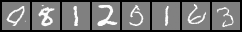

In [8]:
from diffusers import DDPMPipeline

pipe = DDPMPipeline(unet=model, scheduler=noise_scheduler)
images = pipe(batch_size=8).images
show_images(torch.stack([transforms.ToTensor()(i) for i in images]))